# Нейронная сеть прямого распространения (классификация)

## 1. Название и краткая информация о сдаваемом методе (1 абзац)

**Нейронная сеть прямого распространения** (англ. *feedforward neural network*, читается «фидфорвард»; также называют **многослойным перцептроном**, англ. *Multi-Layer Perceptron*, MLP — «эм-эл-пи») — это модель машинного обучения, в которой данные проходят через несколько **слоёв** искусственных нейронов строго в одном направлении: от входа к выходу, без обратных связей. Каждый нейрон вычисляет **взвешенную сумму** своих входов и применяет к ней **функцию активации** (нелинейное преобразование, например `ReLU` — «релу», от англ. *Rectified Linear Unit*, «выпрямленный линейный элемент»), что даёт сети способность выражать сложные нелинейные зависимости. Веса (параметры) сети подбираются на обучающей выборке методом **обратного распространения ошибки** (*backpropagation*, «бэкпропэгейшн») в связке с алгоритмом оптимизации (в `scikit-learn` по умолчанию — `Adam`, «адам», адаптивный метод градиентного спуска). В задаче классификации сеть на выходе выдаёт вероятности принадлежности объекта к каждому из классов, и объект относится к классу с **наибольшей** вероятностью. В этом ноутбуке используется реализация `MLPClassifier` из библиотеки `scikit-learn` (читается «сайкит-лёрн»).

## 2. Блок с используемыми библиотеками

Короткие пояснения к названиям:
- **numpy** (читается «нампай») — численные операции с массивами чисел.
- **pandas** («пэндас») — таблицы (DataFrame, «дата-фрейм») и удобная работа с данными.
- **matplotlib** («мэтплотлиб») — базовая библиотека для графиков.
- **seaborn** («сиборн») — красивые статистические графики поверх matplotlib (в том числе тепловая карта).
- **scikit-learn** («сайкит-лёрн») — библиотека машинного обучения: готовые датасеты, модели и метрики.
- **MLPClassifier** (Multi-Layer Perceptron Classifier, «классификатор на основе многослойного перцептрона») — реализация нейронной сети прямого распространения для задачи классификации.
- **StandardScaler** («стандарт-скейлер») — стандартизация признаков (приведение к нулевому среднему и единичному разбросу); для нейронных сетей это практически обязательный шаг.

In [1]:
# !pip -q install numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Набор данных и вспомогательные инструменты
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Сама модель: нейронная сеть прямого распространения (многослойный перцептрон)
from sklearn.neural_network import MLPClassifier

# Метрики качества
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

# Для повторяемости результатов (одинаковое разбиение и инициализация при каждом запуске)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")


## 3. Блок с описанием и демонстрацией (частичной распечаткой) используемого датасета

В качестве примера возьмём встроенный датасет **Breast Cancer Wisconsin** (Висконсинский набор данных о раке молочной железы) из `scikit-learn`. Это классическая задача **бинарной классификации** (два класса): по 30 числовым признакам (результаты обработки изображений клеточных ядер) нужно определить, является ли опухоль **злокачественной** (`malignant`, класс 0) или **доброкачественной** (`benign`, класс 1). Датасет содержит 569 объектов, полностью числовой и не требует скачивания.

Этот датасет удобен для демонстрации нейронной сети: достаточно много признаков, чтобы сеть могла найти нелинейные зависимости, и достаточно объектов для обучения.

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")          # 0 — злокачественная, 1 — доброкачественная
target_names = list(data.target_names)               # ['malignant', 'benign']

df = X.copy()
df["target"] = y

print("Размерность датасета (строки, столбцы):", df.shape)
print("Имена классов:", target_names)
print("   0 =", target_names[0], "(злокачественная опухоль)")
print("   1 =", target_names[1], "(доброкачественная опухоль)")
print("\nРаспределение классов (сколько объектов каждого типа):")
print(y.value_counts().sort_index())

print("\nПервые 5 строк датасета (часть столбцов):")
display(df.iloc[:5, list(range(5)) + [-1]])

print("\nОписательная статистика по признакам (часть):")
display(df.describe().T.head(10))


Размерность датасета (строки, столбцы): (569, 31)
Имена классов: [np.str_('malignant'), np.str_('benign')]
   0 = malignant (злокачественная опухоль)
   1 = benign (доброкачественная опухоль)

Распределение классов (сколько объектов каждого типа):
target
0    212
1    357
Name: count, dtype: int64

Первые 5 строк датасета (часть столбцов):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,target
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0



Описательная статистика по признакам (часть):


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


**Пояснение к таблицам:** каждая строка — одно наблюдение (одна опухоль), каждый столбец — числовой признак (например, `mean radius` — средний радиус клеточного ядра, `mean texture` — средняя текстура и т.п.), а столбец `target` — это правильный ответ (0 — злокачественная, 1 — доброкачественная).

## 4. Блок с предварительной обработкой датасета

Что делаем:
1. Проверяем **пропуски** (пустые значения) и **дубликаты** (повторяющиеся строки).
2. Разделяем данные на **обучающую** и **тестовую** выборки. Обучающая нужна, чтобы сеть «училась», тестовая — чтобы честно проверить её качество на данных, которых она не видела.
3. Выполняем **стандартизацию** признаков с помощью `StandardScaler` — приводим каждый числовой признак к нулевому среднему и единичному разбросу. **Для нейронных сетей это критически важно:** если признаки измеряются в разных масштабах, обучение идёт плохо и нестабильно (градиенты по одним признакам оказываются на порядки больше, чем по другим).

In [3]:
# 1) Пропуски
missing = df.isna().sum().sort_values(ascending=False)
print("Пропуски по каждому столбцу (если везде 0 — пропусков нет):")
print(missing.head(10))

# 2) Дубликаты
dup_count = df.duplicated().sum()
print("\nКоличество полностью совпадающих строк (дубликатов):", dup_count)

# 3) Разделение на обучающую и тестовую выборки (сохраняя доли классов — stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# 4) Стандартизация: обучаем scaler ТОЛЬКО на train и применяем к test,
#    чтобы не было "подглядывания" в тестовые данные.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Оформим обратно в DataFrame — так удобнее смотреть
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\nРазмеры выборок:")
print("X_train:", X_train_scaled.shape, "| X_test:", X_test_scaled.shape)
print("\nДоли классов в обучающей выборке:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nДоли классов в тестовой выборке:")
print(y_test.value_counts(normalize=True).sort_index())

print("\nПервые строки обучающей выборки после стандартизации (часть столбцов):")
display(X_train_scaled.iloc[:5, :6])


Пропуски по каждому столбцу (если везде 0 — пропусков нет):
mean radius               0
mean texture              0
mean perimeter            0
mean area                 0
mean smoothness           0
mean compactness          0
mean concavity            0
mean concave points       0
mean symmetry             0
mean fractal dimension    0
dtype: int64

Количество полностью совпадающих строк (дубликатов): 0

Размеры выборок:
X_train: (455, 30) | X_test: (114, 30)

Доли классов в обучающей выборке:
target
0    0.373626
1    0.626374
Name: proportion, dtype: float64

Доли классов в тестовой выборке:
target
0    0.368421
1    0.631579
Name: proportion, dtype: float64

Первые строки обучающей выборки после стандартизации (часть столбцов):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
546,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718
432,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288
174,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154
221,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762
289,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099


## 5. Блок с тепловой картой

Тепловая карта (англ. *heatmap*, «хитмап» — «карта тепла») корреляций показывает, **насколько сильно связаны** друг с другом признаки. Значение корреляции изменяется от -1 до 1:
- около 1 — сильная прямая связь (растёт один — растёт другой);
- около -1 — сильная обратная связь;
- около 0 — связи почти нет.

Для нейронной сети сильные корреляции между признаками не являются проблемой (сеть сама научится использовать их по-своему), но карта полезна для понимания структуры данных и того, какие признаки наиболее сильно связаны с целевой переменной `target`.

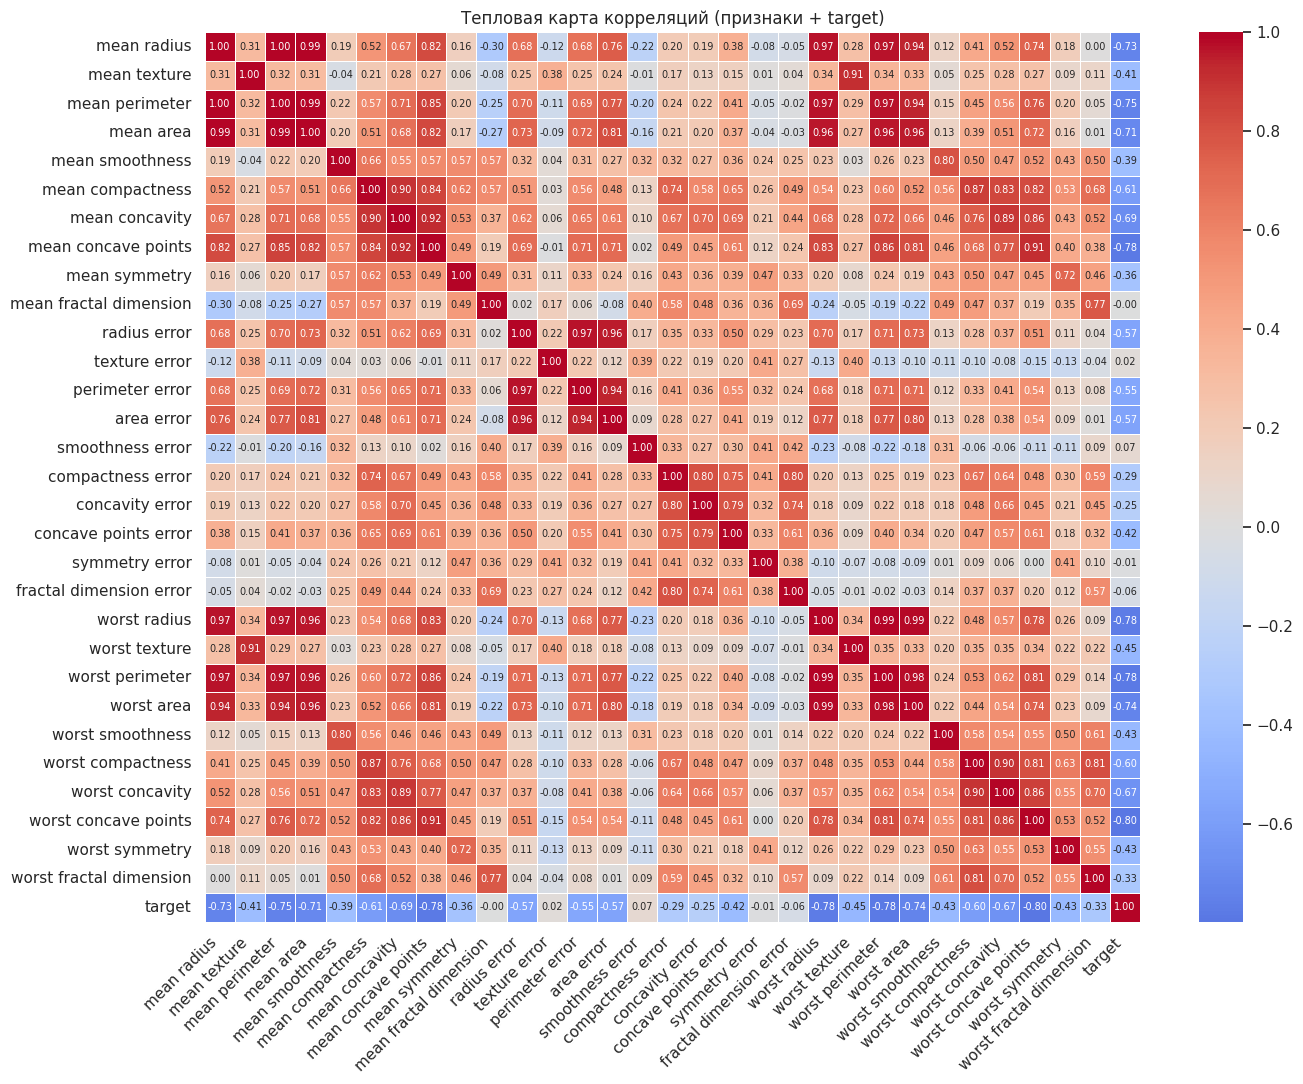

Корреляции признаков с target (по убыванию модуля), топ-10:
worst concave points   -0.798
worst perimeter        -0.783
mean concave points    -0.780
worst radius           -0.776
mean perimeter         -0.745
worst area             -0.738
mean radius            -0.732
mean area              -0.713
mean concavity         -0.692
worst concavity        -0.668
Name: target, dtype: float64


In [4]:
# Корреляции считаем по обучающей выборке вместе с целевой переменной,
# чтобы увидеть и связи между признаками, и связь каждого признака с target.
train_full = X_train.copy()
train_full["target"] = y_train

corr = train_full.corr(numeric_only=True)

plt.figure(figsize=(14, 11))
sns.heatmap(
    corr,
    annot=True,        # подписываем значения
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False,
    linewidths=0.5,
    annot_kws={"size": 7},
)
plt.title("Тепловая карта корреляций (признаки + target)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Корреляции признаков с target (по убыванию модуля), топ-10:")
top_corr = corr["target"].drop("target")
print(top_corr.reindex(top_corr.abs().sort_values(ascending=False).index).head(10).round(3))


## 6. Блок с обучением модели

Обучаем **MLPClassifier** — нейронную сеть прямого распространения. Настраиваемые параметры:
- `hidden_layer_sizes=(64, 32)` — **архитектура** сети: два скрытых слоя, 64 нейрона в первом и 32 во втором. Вход — 30 признаков, выход — 2 класса (вероятности).
- `activation="relu"` — **функция активации** в скрытых слоях: `ReLU(x) = max(0, x)`. Самый распространённый и быстрый в обучении вариант.
- `solver="adam"` — **оптимизатор** (алгоритм, подбирающий веса). `Adam` («адам») — адаптивный метод градиентного спуска, хороший выбор по умолчанию.
- `alpha=1e-4` — коэффициент **регуляризации** (штраф за большие веса), защищает от переобучения.
- `max_iter=500` — максимальное число **эпох** (полных проходов по обучающей выборке).
- `early_stopping=True` — ранняя остановка: если качество на проверочной части перестаёт расти, обучение прекращается (защита от переобучения и экономия времени).
- `random_state=RANDOM_STATE` — фиксируем случайность, чтобы результаты были воспроизводимыми.

Для надёжности дополнительно проверим модель **кросс-валидацией** (англ. *cross-validation*, «перекрёстная проверка»): обучающая выборка разбивается на 5 частей, модель 5 раз обучается и проверяется на разных частях. Это даёт более честную оценку качества, чем один замер.

In [5]:
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=32,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
)

# Кросс-валидация на обучающей выборке (5 частей)
cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

print("Точности на 5 частях кросс-валидации:", np.round(cv_scores, 4))
print(f"Средняя точность по кросс-валидации: {cv_scores.mean():.4f}")
print(f"Стандартное отклонение:              {cv_scores.std():.4f}")

# Обучаем модель на всей обучающей выборке
model.fit(X_train_scaled, y_train)
print("\nМодель обучена.")

# Посмотрим ключевые параметры, которые получились после обучения
print(f"\nАрхитектура сети: вход = {X_train_scaled.shape[1]} нейронов, "
      f"скрытые слои = {model.hidden_layer_sizes}, выход = {len(model.classes_)} нейрона.")
print(f"Сделано итераций (эпох) обучения: {model.n_iter_}")
print(f"Итоговое значение функции потерь на обучении: {model.loss_:.6f}")

print("\nКоличество параметров (весов и смещений) в каждом слое:")
for i, (w, b) in enumerate(zip(model.coefs_, model.intercepts_), start=1):
    print(f"   Слой {i}: веса {w.shape} + смещения {b.shape} = {w.size + b.size} параметров")
total_params = sum(w.size + b.size for w, b in zip(model.coefs_, model.intercepts_))
print(f"Итого параметров сети: {total_params}")


Точности на 5 частях кросс-валидации: [0.9341 0.978  0.967  0.978  0.978 ]
Средняя точность по кросс-валидации: 0.9670
Стандартное отклонение:              0.0170

Модель обучена.

Архитектура сети: вход = 30 нейронов, скрытые слои = (64, 32), выход = 2 нейрона.
Сделано итераций (эпох) обучения: 24
Итоговое значение функции потерь на обучении: 0.025320

Количество параметров (весов и смещений) в каждом слое:
   Слой 1: веса (30, 64) + смещения (64,) = 1984 параметров
   Слой 2: веса (64, 32) + смещения (32,) = 2080 параметров
   Слой 3: веса (32, 1) + смещения (1,) = 33 параметров
Итого параметров сети: 4097


## 7. Блок с прогнозами модели

Делаем прогнозы на тестовой выборке. Считаем:
- **accuracy** (точность — доля правильных ответов),
- **classification report** (подробный отчёт: precision, recall, F1 по каждому классу — подробное описание в markdown-блоке ниже),
- **confusion matrix** (матрица ошибок: кто с кем путается),
- **ROC-AUC** — площадь под ROC-кривой (чем ближе к 1, тем лучше модель разделяет классы).

In [6]:
# 1) Метки (какой класс предсказала модель)
y_pred = model.predict(X_test_scaled)

# 2) Вероятности каждого класса для каждого объекта
y_proba = model.predict_proba(X_test_scaled)

# 3) Точность
acc = accuracy_score(y_test, y_pred)
print(f"Точность на тестовой выборке (accuracy): {acc:.4f}")

# 4) Отчёт по классификации
print("\nОтчёт по классификации (precision / recall / f1-score по каждому классу):")
print(classification_report(y_test, y_pred, target_names=target_names))

# 5) Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок (строки — истина, столбцы — прогноз):")
print(pd.DataFrame(cm, index=[f"истина: {n}" for n in target_names],
                        columns=[f"прогноз: {n}" for n in target_names]))

# 6) ROC-AUC для бинарной классификации
auc_val = roc_auc_score(y_test, y_proba[:, 1])
print(f"\nROC-AUC: {auc_val:.4f}")

# 7) Частичная распечатка прогнозов: истина, прогноз и вероятности
preview = pd.DataFrame({
    "истина": y_test.values,
    "прогноз": y_pred,
    f"P({target_names[0]})": y_proba[:, 0].round(3),
    f"P({target_names[1]})": y_proba[:, 1].round(3),
}).reset_index(drop=True)

print("\nПервые 15 прогнозов (с вероятностями классов):")
display(preview.head(15))


Точность на тестовой выборке (accuracy): 0.9737

Отчёт по классификации (precision / recall / f1-score по каждому классу):
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Матрица ошибок (строки — истина, столбцы — прогноз):
                   прогноз: malignant  прогноз: benign
истина: malignant                  41                1
истина: benign                      2               70

ROC-AUC: 0.9964

Первые 15 прогнозов (с вероятностями классов):


,истина,прогноз,P(malignant),P(benign)
0,0,0,0.999,0.001
1,1,1,0.000,1.000
2,0,0,0.965,0.035
3,1,1,0.403,0.597
4,0,0,1.000,0.000
5,1,1,0.008,0.992
6,1,1,0.001,0.999
7,0,0,0.997,0.003
8,0,0,0.990,0.010
9,0,0,1.000,0.000


**Пояснение терминов в отчёте:**
- **precision** («прецижн», точность по классу) — из всех объектов, которым модель поставила этот класс, какая доля действительно этого класса.
- **recall** («риколл», полнота) — из всех объектов этого класса, какую долю модель нашла.
- **f1-score** — гармоническое среднее precision и recall; общая оценка по классу.
- **support** («саппорт») — сколько объектов этого класса в тестовой выборке.
- **ROC-AUC** (Receiver Operating Characteristic — Area Under Curve, «площадь под рабочей характеристикой приёмника») — площадь под ROC-кривой; чем ближе к 1, тем лучше модель различает классы.

## 8. Блок с графиками выходных результатов

Построим:
1. **Матрицу ошибок** в виде тепловой карты.
2. **Кривую обучения** — как падало значение функции потерь во время обучения сети (это полезный индикатор того, что сеть действительно училась).
3. **ROC-кривую** и её AUC.
4. **Распределение вероятностей** предсказанного класса на тестовой выборке.
5. **Границу решений** на плоскости PCA (метод главных компонент — способ сжать 30 признаков в 2 для картинки).

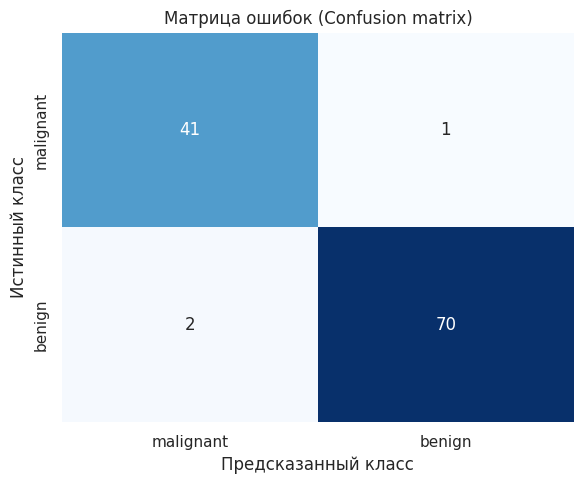

In [7]:
# 8.1 Матрица ошибок как тепловая карта
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("Матрица ошибок (Confusion matrix)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.tight_layout()
plt.show()


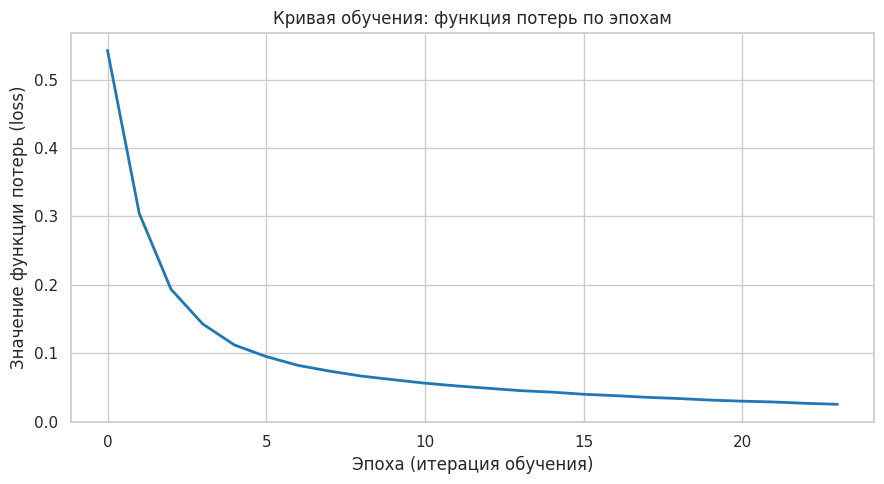

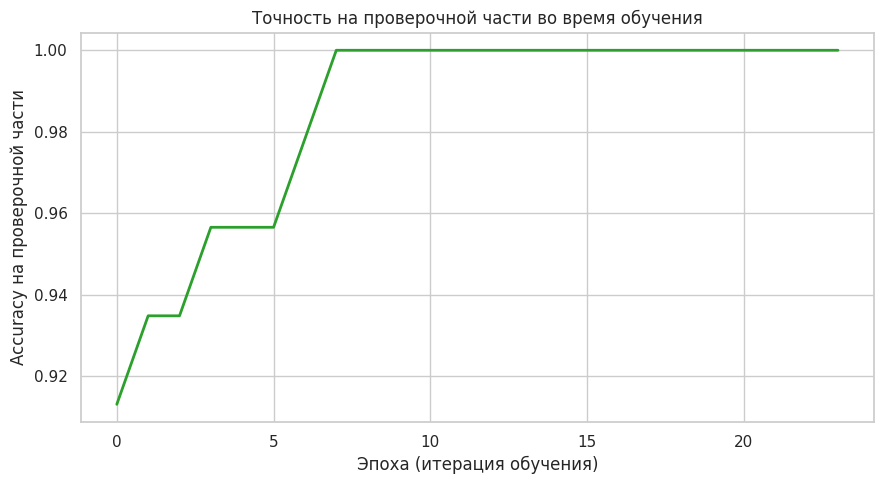

In [8]:
# 8.2 Кривая обучения: значение функции потерь по эпохам
# model.loss_curve_ содержит значение loss (функции потерь) на каждой итерации обучения.
# Это хороший индикатор: если loss устойчиво падает — сеть учится, если выходит на плато — сеть сошлась.

plt.figure(figsize=(9, 5))
plt.plot(model.loss_curve_, color="#1f77b4", linewidth=2)
plt.title("Кривая обучения: функция потерь по эпохам")
plt.xlabel("Эпоха (итерация обучения)")
plt.ylabel("Значение функции потерь (loss)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Если при early_stopping=True была собрана история качества на проверочной части — покажем и её.
if hasattr(model, "validation_scores_") and model.validation_scores_ is not None:
    plt.figure(figsize=(9, 5))
    plt.plot(model.validation_scores_, color="#2ca02c", linewidth=2)
    plt.title("Точность на проверочной части во время обучения")
    plt.xlabel("Эпоха (итерация обучения)")
    plt.ylabel("Accuracy на проверочной части")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


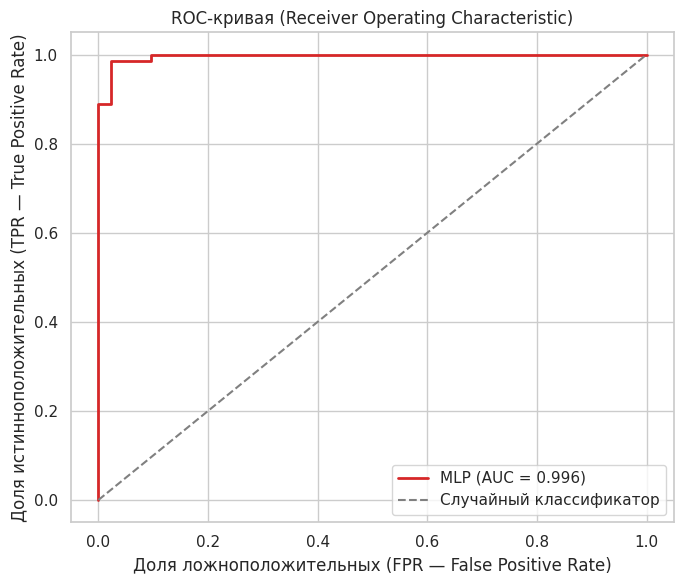

In [9]:
# 8.3 ROC-кривая для бинарной классификации
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#d62728", linewidth=2, label=f"MLP (AUC = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Случайный классификатор")
plt.xlabel("Доля ложноположительных (FPR — False Positive Rate)")
plt.ylabel("Доля истинноположительных (TPR — True Positive Rate)")
plt.title("ROC-кривая (Receiver Operating Characteristic)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


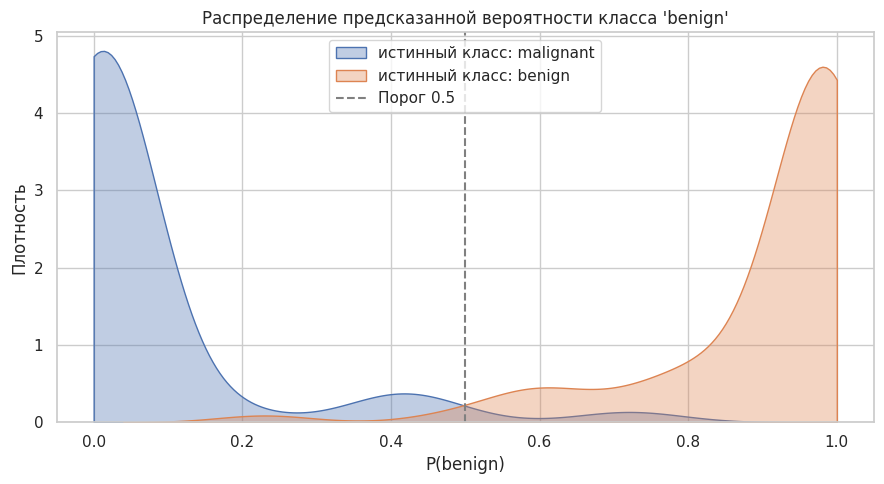

In [10]:
# 8.4 Распределение вероятностей, которые сеть выдаёт для положительного класса (benign).
# В идеале объекты двух классов должны давать разные распределения этой вероятности:
# злокачественные (0) — ближе к 0, доброкачественные (1) — ближе к 1.

proba_pos = y_proba[:, 1]

plt.figure(figsize=(9, 5))
for cls in np.unique(y_test):
    mask = y_test.values == cls
    sns.kdeplot(
        proba_pos[mask],
        label=f"истинный класс: {target_names[cls]}",
        fill=True,
        alpha=0.35,
        clip=(0, 1),
    )
plt.axvline(0.5, color="gray", linestyle="--", label="Порог 0.5")
plt.title(f"Распределение предсказанной вероятности класса '{target_names[1]}'")
plt.xlabel(f"P({target_names[1]})")
plt.ylabel("Плотность")
plt.legend()
plt.tight_layout()
plt.show()


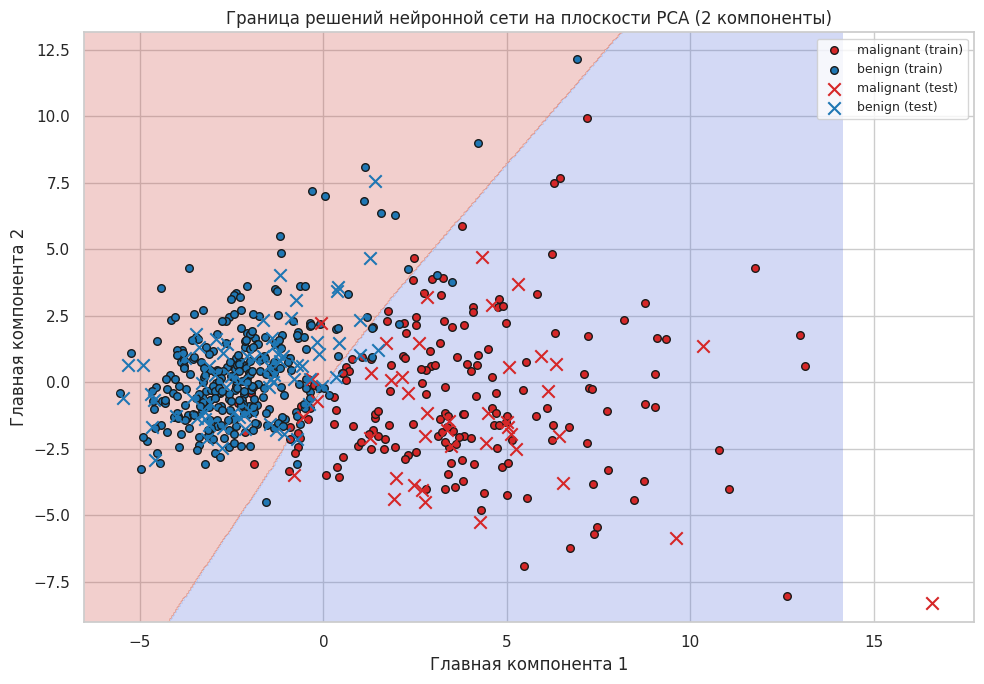

Доля объяснённой дисперсии двумя компонентами PCA: 0.634


In [11]:
# 8.5 Граница решений на плоскости PCA (метод главных компонент)
# PCA сжимает 30 признаков в 2, чтобы можно было нарисовать картинку.
# Обучим отдельную копию MLPClassifier на этих 2 компонентах — только для визуализации.

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model_pca = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    max_iter=500,
    random_state=RANDOM_STATE,
)
model_pca.fit(X_train_pca, y_train)

# Сетка точек, чтобы закрасить области классов
x_min = X_train_pca[:, 0].min() - 1
x_max = X_train_pca[:, 0].max() + 1
y_min = X_train_pca[:, 1].min() - 1
y_max = X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400),
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_pca.predict(grid).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")

colors = ["#d62728", "#1f77b4"]  # красный — злокачественная, синий — доброкачественная
for i, cls in enumerate(np.unique(y_train)):
    mask = y_train.values == cls
    plt.scatter(
        X_train_pca[mask, 0], X_train_pca[mask, 1],
        s=30, c=colors[i], edgecolor="k",
        label=f"{target_names[i]} (train)"
    )

# Тестовые точки — крестиками
for i, cls in enumerate(np.unique(y_test)):
    mask = y_test.values == cls
    plt.scatter(
        X_test_pca[mask, 0], X_test_pca[mask, 1],
        s=80, c=colors[i], marker="x",
        label=f"{target_names[i]} (test)"
    )

plt.title("Граница решений нейронной сети на плоскости PCA (2 компоненты)")
plt.xlabel("Главная компонента 1")
plt.ylabel("Главная компонента 2")
plt.legend(loc="best", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Доля объяснённой дисперсии двумя компонентами PCA: {pca.explained_variance_ratio_.sum():.3f}")


---

### Короткий вывод

Модель **нейронной сети прямого распространения** (MLP) с двумя скрытыми слоями (64 и 32 нейрона) обучена на датасете Breast Cancer Wisconsin и показывает высокую точность бинарной классификации (злокачественная / доброкачественная опухоль). Кросс-валидация подтверждает устойчивость результата. Графики показывают:
- **матрицу ошибок** (где именно модель путается между классами);
- **кривую обучения** (видно, как сеть училась и сошлась ли она);
- **ROC-кривую** (как хорошо разделяются классы по вероятностям);
- **распределение предсказанных вероятностей** по классам (видно, насколько уверенно сеть разделяет объекты);
- **границу решений** на плоскости PCA (визуальное представление того, как сеть «разрезает» пространство признаков).

Благодаря нелинейным функциям активации и нескольким скрытым слоям нейронная сеть способна выявлять сложные зависимости между признаками, что в сочетании со стандартизацией данных и регуляризацией даёт стабильно хорошее качество на данной задаче.